In [1]:
!pip install -q mlflow
!pip install -q --no-cache-dir --force-reinstall --no-deps git+https://github.com/RayenSansa03/aeroguard.git@main

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.

In [2]:
print("--- autoencodeurs.py sur GitHub (main) ---")
!curl -s https://raw.githubusercontent.com/RayenSansa03/aeroguard/main/src/aeroguard/autoencodeurs.py | grep -n "^def "
print("\n--- autoencodeurs.py installé dans Colab ---")
!grep -n "^def " $(python -c "import aeroguard, os; print(os.path.dirname(aeroguard.__file__))")/autoencodeurs.py

--- autoencodeurs.py sur GitHub (main) ---
8:def statistiques_features(X):
19:def standardiser(X, moyennes, ecarts):
24:def creer_autoencodeur_dense(
53:def erreur_reconstruction(modele, X, par_feature=False):
65:def creer_autoencodeur_conv1d(
113:def erreur_reconstruction_fenetres(modele, X, par_canal=False, taille_lot=256):

--- autoencodeurs.py installé dans Colab ---
8:def statistiques_features(X):
19:def standardiser(X, moyennes, ecarts):
24:def creer_autoencodeur_dense(
53:def erreur_reconstruction(modele, X, par_feature=False):
65:def creer_autoencodeur_conv1d(
113:def erreur_reconstruction_fenetres(modele, X, par_canal=False, taille_lot=256):


In [3]:
from google.colab import drive
drive.mount("/content/drive")

import json
import math
import os
import shutil
import time

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import tensorflow as tf

from aeroguard.sequences import CAPTEURS

DOSSIER = "/content/drive/MyDrive/aeroguard"
DOSSIER_MLFLOW_LOCAL = "/content/mlflow"
DOSSIER_MLFLOW_DRIVE = f"{DOSSIER}/mlflow"
if os.path.exists(DOSSIER_MLFLOW_DRIVE) and not os.path.exists(DOSSIER_MLFLOW_LOCAL):
    shutil.copytree(DOSSIER_MLFLOW_DRIVE, DOSSIER_MLFLOW_LOCAL)
if os.path.exists(f"{DOSSIER}/mlruns") and not os.path.exists("/content/mlruns"):
    shutil.copytree(f"{DOSSIER}/mlruns", "/content/mlruns")
os.makedirs(DOSSIER_MLFLOW_LOCAL, exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{DOSSIER_MLFLOW_LOCAL}/mlflow.db")

archive = np.load(f"{DOSSIER}/data/processed/fenetres_v4.npz")
X_train, y_train = archive["X_train"], archive["y_train"]
X_val, y_val = archive["X_val"], archive["y_val"]
CANAUX = [str(c) for c in archive["canaux"]]
NOMBRE_CAPTEURS = len(CAPTEURS)
assert CANAUX[:NOMBRE_CAPTEURS] == list(CAPTEURS), "Les capteurs doivent être les premiers canaux."

infos = pd.read_parquet(f"{DOSSIER}/data/processed/fenetres_v4_infos.parquet")
infos_val = infos[infos["groupe"] == "val"].reset_index(drop=True)

sains_train = y_train == 0
sains_val = y_val == 0
LONGUEUR, NOMBRE_CANAUX = X_train.shape[1:]
print("TensorFlow", tf.__version__, "| GPU :", tf.config.list_physical_devices("GPU"))
print(f"Fenêtres saines pour apprendre : {sains_train.sum()} | validation : {sains_val.sum()} saines, "
      f"{(~sains_val).sum()} usées")
print(f"Entrée : {LONGUEUR} s × {NOMBRE_CANAUX} canaux → sortie : {NOMBRE_CAPTEURS} capteurs")

Mounted at /content/drive
TensorFlow 2.21.0 | GPU : []
Fenêtres saines pour apprendre : 4384 | validation : 976 saines, 2300 usées
Entrée : 256 s × 18 canaux → sortie : 14 capteurs


In [4]:
from aeroguard.autoencodeurs import creer_autoencodeur_conv1d
from aeroguard.reseaux import nombre_parametres_entrainables

autoencodeur = creer_autoencodeur_conv1d(LONGUEUR, NOMBRE_CANAUX, canaux_sortie=NOMBRE_CAPTEURS)
autoencodeur.summary()
print("Paramètres entraînables :", nombre_parametres_entrainables(autoencodeur))

Model: "aeroguard_autoencodeur_conv1d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fenetre (InputLayer)            │ (None, 256, 18)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encodeur_1 (Conv1D)             │ (None, 256, 32)        │         4,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ compression_1 (MaxPooling1D)    │ (None, 128, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encodeur_2 (Conv1D)             │ (None, 128, 16)        │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ compression_2 (MaxPooling1D)    │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encodeur_3 (Conv1D)             │ (None, 64, 8)          │           904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ compression_3 (MaxPooling1D)    │ (None, 32, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decompression_1 (UpSampling1D)  │ (None, 64, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decodeur_1 (Conv1D)             │ (None, 64, 8)          │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decompression_2 (UpSampling1D)  │ (None, 128, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decodeur_2 (Conv1D)             │ (None, 128, 16)        │           912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decompression_3 (UpSampling1D)  │ (None, 256, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decodeur_3 (Conv1D)             │ (None, 256, 32)        │         3,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Conv1D)         │ (None, 256, 14)        │         3,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,702 (65.24 KB)

 Trainable params: 16,702 (65.24 KB)

 Non-trainable params: 0 (0.00 B)

Paramètres entraînables : 16702


In [5]:
from aeroguard.reseaux import creer_callbacks

os.makedirs("/content/checkpoints", exist_ok=True)
X_sains_train = X_train[sains_train]
X_sains_val = X_val[sains_val]

print("Appareil utilisé :", "GPU" if tf.config.list_physical_devices("GPU") else "CPU",
      "— l'entraînement peut prendre 5 à 15 minutes, laisse l'onglet ouvert.")

debut = time.perf_counter()
historique = autoencodeur.fit(
    X_sains_train, X_sains_train[:, :, :NOMBRE_CAPTEURS],   # entrée : 18 canaux → cible : 14 capteurs
    validation_data=(X_sains_val, X_sains_val[:, :, :NOMBRE_CAPTEURS]),
    epochs=150,          # CPU : limite plus basse (EarlyStopping arrête souvent avant)
    batch_size=256,      # CPU : lots plus gros = moins d'étapes par époque = plus rapide
    callbacks=creer_callbacks("/content/checkpoints/autoencodeur_conv1d.keras", patience=15),
    verbose=2,           # une ligne par époque, pour suivre la progression
)
duree_entrainement = time.perf_counter() - debut

courbes = pd.DataFrame(historique.history)
courbes.index += 1
meilleure_epoque = int(courbes["val_loss"].idxmin())
print(f"{len(courbes)} époques en {duree_entrainement:.0f} s — meilleure époque : {meilleure_epoque}")
courbes.iloc[[0, meilleure_epoque - 1, len(courbes) - 1]].round(4)

Appareil utilisé : CPU — l'entraînement peut prendre 5 à 15 minutes, laisse l'onglet ouvert.
Epoch 1/150
18/18 - 14s - 786ms/step - loss: 0.6005 - val_loss: 0.1807 - learning_rate: 0.0010
Epoch 2/150
18/18 - 4s - 245ms/step - loss: 0.1143 - val_loss: 0.0536 - learning_rate: 0.0010
Epoch 3/150
18/18 - 4s - 240ms/step - loss: 0.0391 - val_loss: 0.0285 - learning_rate: 0.0010
Epoch 4/150
18/18 - 7s - 411ms/step - loss: 0.0237 - val_loss: 0.0192 - learning_rate: 0.0010
Epoch 5/150
18/18 - 4s - 237ms/step - loss: 0.0172 - val_loss: 0.0148 - learning_rate: 0.0010
Epoch 6/150
18/18 - 4s - 243ms/step - loss: 0.0137 - val_loss: 0.0119 - learning_rate: 0.0010
Epoch 7/150
18/18 - 7s - 361ms/step - loss: 0.0111 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 8/150
18/18 - 8s - 450ms/step - loss: 0.0086 - val_loss: 0.0075 - learning_rate: 0.0010
Epoch 9/150
18/18 - 8s - 418ms/step - loss: 0.0072 - val_loss: 0.0065 - learning_rate: 0.0010
Epoch 10/150
18/18 - 4s - 242ms/step - loss: 0.0063 - val_lo

,loss,val_loss,learning_rate
1,0.6005,0.1807,0.001
150,0.0016,0.0016,0.000
150,0.0016,0.0016,0.000


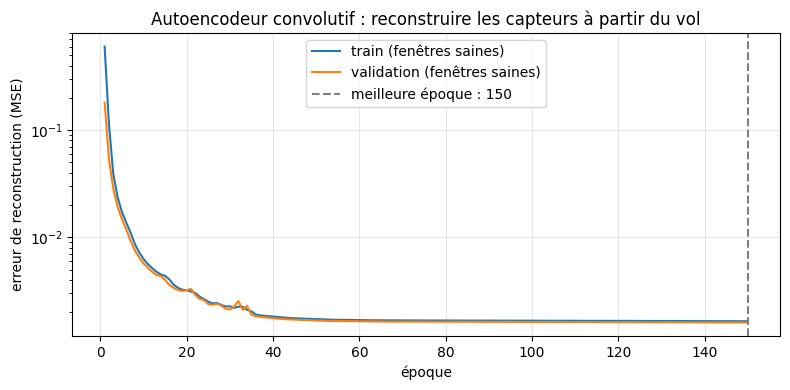

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(courbes.index, courbes["loss"], label="train (fenêtres saines)")
plt.plot(courbes.index, courbes["val_loss"], label="validation (fenêtres saines)")
plt.axvline(meilleure_epoque, color="gray", linestyle="--", label=f"meilleure époque : {meilleure_epoque}")
plt.yscale("log")
plt.xlabel("époque")
plt.ylabel("erreur de reconstruction (MSE)")
plt.title("Autoencodeur convolutif : reconstruire les capteurs à partir du vol")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/53_courbes_autoencodeur_conv1d.png", dpi=150)
plt.show()

In [7]:
from scipy.stats import spearmanr
from sklearn.metrics import average_precision_score, roc_auc_score

from aeroguard.autoencodeurs import erreur_reconstruction_fenetres
from aeroguard.sequences import agreger_par_vol

erreurs_fenetres_val = erreur_reconstruction_fenetres(autoencodeur, X_val)
vols_val = agreger_par_vol(infos_val, erreurs_fenetres_val).rename(columns={"proba": "erreur"})
y_vols_val = vols_val["usure"].astype(int).to_numpy()
sains_vols_val = y_vols_val == 0

mediane_sains = np.median(vols_val.loc[sains_vols_val, "erreur"])
mediane_uses = np.median(vols_val.loc[~sains_vols_val, "erreur"])
pr_auc_conv = average_precision_score(y_vols_val, vols_val["erreur"])
roc_auc_conv = roc_auc_score(y_vols_val, vols_val["erreur"])
spearman_conv, _ = spearmanr(vols_val["RUL"], vols_val["erreur"])

comparaison = pd.DataFrame({
    "entree": ["126 features résumées", "4 fenêtres × 256 s × 18 canaux"],
    "ratio_medianes_uses_sains": [6.2, mediane_uses / mediane_sains],
    "pr_auc_validation": [0.953, pr_auc_conv],
    "spearman_rul": [-0.89, spearman_conv],
}, index=["autoencodeur dense (5.1)", "autoencodeur conv1d (5.3)"])
print(f"{len(vols_val)} vols de validation | ROC-AUC conv1d : {roc_auc_conv:.3f}")
comparaison.round(3)

819 vols de validation | ROC-AUC conv1d : 0.712


,entree,ratio_medianes_uses_sains,pr_auc_validation,spearman_rul
autoencodeur dense (5.1),126 features résumées,6.200,0.953,-0.890
autoencodeur conv1d (5.3),4 fenêtres × 256 s × 18 canaux,1.536,0.864,-0.595


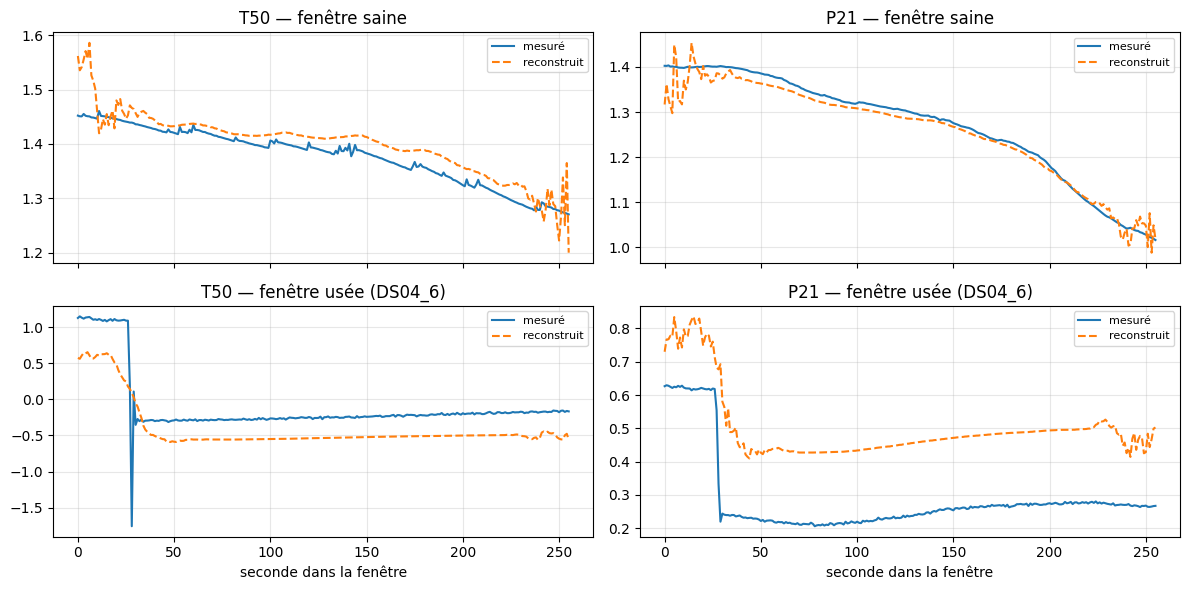

In [8]:
predictions = autoencodeur.predict(X_val, batch_size=256, verbose=0)
indice_sain = int(np.where(sains_val)[0][0])
fenetres_ds04 = np.where((infos_val["moteur"] == "DS04_6").to_numpy() & ~sains_val)[0]
indice_use = int(fenetres_ds04[-1])        # dernière fenêtre usée du moteur fan DS04_6

figure, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
for ligne, (indice, nom) in enumerate([(indice_sain, "fenêtre saine"), (indice_use, "fenêtre usée (DS04_6)")]):
    for colonne, capteur in enumerate(["T50", "P21"]):
        c = CANAUX.index(capteur)
        axes[ligne, colonne].plot(X_val[indice, :, c], label="mesuré")
        axes[ligne, colonne].plot(predictions[indice, :, c], linestyle="--", label="reconstruit")
        axes[ligne, colonne].set_title(f"{capteur} — {nom}")
        axes[ligne, colonne].grid(alpha=0.3)
        axes[ligne, colonne].legend(fontsize=8)
for axe in axes[1]:
    axe.set_xlabel("seconde dans la fenêtre")
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/53_reconstruction_fenetre.png", dpi=150)
plt.show()

In [9]:
from aeroguard.anomalies import seuil_percentile
from aeroguard.metier import evaluer_alerte_score

infos_vols_val = vols_val[["moteur", "cycle", "RUL"]]
lignes = []
for p in [90, 95, 97.5, 99]:
    seuil = seuil_percentile(vols_val.loc[sains_vols_val, "erreur"], p)
    for k in (1, 3, 5):
        scores = evaluer_alerte_score(y_vols_val, vols_val["erreur"], seuil, infos_vols_val, k=k,
                                      col_moteur="moteur")
        lignes.append({"percentile": p, "k": k, "seuil": seuil, **scores})
balayage = pd.DataFrame(lignes)

# Même règle qu'en 5.2, fixée à l'avance
candidats = balayage[balayage["moteurs_detectes"] == balayage["moteurs"]]
assert len(candidats) > 0, "Aucun réglage ne prévient tous les moteurs."
choix = candidats.sort_values(["fausses_alarmes_total", "avance_moyenne"], ascending=[True, False]).iloc[0]
CONFIG_CONV = {"percentile": float(choix["percentile"]), "seuil": float(choix["seuil"]), "k": int(choix["k"]),
               "calibre_sur": "erreurs moyennes par vol des vols sains de validation"}
print("Configuration figée :", CONFIG_CONV)

colonnes_vues = ["percentile", "k", "moteurs_detectes", "avance_moyenne", "fausses_alarmes_total",
                 "moteurs_avec_fausse_alarme"]
display(balayage[colonnes_vues].round(1))

face_a_face = pd.DataFrame({
    "moteurs_detectes": [11, 11, int(choix["moteurs_detectes"])],
    "avance_moyenne": [42.5, 29.2, choix["avance_moyenne"]],
    "fausses_alarmes_total": [2, 0, int(choix["fausses_alarmes_total"])],
}, index=["XGBoost supervisé (v3)", "autoencodeur dense p90 k5 (5.2)",
          f"autoencodeur conv1d p{CONFIG_CONV['percentile']:g} k{CONFIG_CONV['k']} (5.3)"])
face_a_face.round(1)

Configuration figée : {'percentile': 90.0, 'seuil': 0.0026907847408438107, 'k': 5, 'calibre_sur': 'erreurs moyennes par vol des vols sains de validation'}


,percentile,k,moteurs_detectes,avance_moyenne,fausses_alarmes_total,moteurs_avec_fausse_alarme
0,90.0,1,11,42.6,25,10
1,90.0,3,11,10.9,1,1
2,90.0,5,11,7.5,0,0
3,95.0,1,11,36.2,13,6
4,95.0,3,11,8.6,1,1
5,95.0,5,11,5.8,0,0
6,97.5,1,11,31.4,7,4
7,97.5,3,11,6.5,0,0
8,97.5,5,11,4.5,0,0
9,99.0,1,11,19.3,3,2


,moteurs_detectes,avance_moyenne,fausses_alarmes_total
XGBoost supervisé (v3),11,42.5,2
autoencodeur dense p90 k5 (5.2),11,29.2,0
autoencodeur conv1d p90 k5 (5.3),11,7.5,0


In [10]:
erreurs_par_canal = erreur_reconstruction_fenetres(autoencodeur, X_val, par_canal=True)
surprise = pd.Series(
    np.median(erreurs_par_canal[~sains_val], axis=0) / np.median(erreurs_par_canal[sains_val], axis=0),
    index=CANAUX[:NOMBRE_CAPTEURS],
).sort_values(ascending=False)
print("Erreur médiane des fenêtres usées ÷ fenêtres saines, par capteur :")
surprise.round(1)

Erreur médiane des fenêtres usées ÷ fenêtres saines, par capteur :


,0
T50,2.8
T48,2.4
Nc,1.9
T30,1.7
P40,1.4
Ps30,1.3
Nf,1.3
T24,1.2
P21,1.2
P24,1.1


In [11]:
def scores_numeriques(scores):
    """Garde seulement les nombres valides (MLflow refuse le texte et les NaN)."""
    propres = {}
    for cle, valeur in scores.items():
        try:
            nombre = float(valeur)
        except (TypeError, ValueError):
            continue
        if not math.isnan(nombre):
            propres[cle] = nombre
    return propres


CHEMIN_MODELE = f"{DOSSIER}/models/autoencodeur_conv1d_v5.keras"
CHEMIN_CONFIG = f"{DOSSIER}/models/autoencodeur_conv1d_v5_alerte.json"
autoencodeur.save(CHEMIN_MODELE)
with open(CHEMIN_CONFIG, "w") as f:
    json.dump(CONFIG_CONV, f, indent=2)
balayage.to_csv(f"{DOSSIER}/results/v5_balayage_seuil_conv1d.csv", index=False)
bilan_choisi = evaluer_alerte_score(y_vols_val, vols_val["erreur"], CONFIG_CONV["seuil"], infos_vols_val,
                                    k=CONFIG_CONV["k"], col_moteur="moteur")

mlflow.set_experiment("aeroguard-anomalies")
with mlflow.start_run(run_name="autoencodeur_conv1d"):
    mlflow.log_params({"modele": "autoencodeur_conv1d", "entree": f"{LONGUEUR}x{NOMBRE_CANAUX}",
                       "sortie": f"{NOMBRE_CAPTEURS} capteurs", "filtres": "32-16-8", "goulot": "32x8",
                       "parametres_entrainables": nombre_parametres_entrainables(autoencodeur)})
    mlflow.log_metrics({"perte_val_min": float(courbes["val_loss"].min()), "meilleure_epoque": meilleure_epoque,
                        "duree_entrainement_s": duree_entrainement, "pr_auc_val": pr_auc_conv,
                        "roc_auc_val": roc_auc_conv, "spearman_rul": spearman_conv,
                        "ratio_erreur_mediane": mediane_uses / mediane_sains})
    for figure in ["53_courbes_autoencodeur_conv1d", "53_reconstruction_fenetre"]:
        mlflow.log_artifact(f"{DOSSIER}/results/figures/{figure}.png")
    mlflow.log_artifact(CHEMIN_MODELE)
    mlflow.set_tags({"lecon": "5.3", "tache": "anomalie", "jeu": "validation"})

mlflow.set_experiment("aeroguard-alerte")
with mlflow.start_run(run_name="autoencodeur_conv1d_alerte") as run:
    mlflow.log_params({"modele": "autoencodeur_conv1d", "type": "non supervisé",
                       "percentile": CONFIG_CONV["percentile"], "seuil": round(CONFIG_CONV["seuil"], 4),
                       "fenetre_confirmation": CONFIG_CONV["k"]})
    mlflow.log_metrics(scores_numeriques(bilan_choisi))
    mlflow.log_artifact(CHEMIN_CONFIG)
    mlflow.log_artifact(f"{DOSSIER}/results/v5_balayage_seuil_conv1d.csv")
    mlflow.set_tags({"lecon": "5.3", "tache": "alerte", "jeu": "validation"})
print("✅ Modèle, configuration et runs enregistrés :", run.info.run_id[:8])

✅ Modèle, configuration et runs enregistrés : 284a02a4


In [12]:
dossiers_artifacts = set()
for experience in mlflow.search_experiments():
    emplacement = experience.artifact_location.replace("file://", "")
    if emplacement.startswith("/content") and not emplacement.startswith("/content/drive"):
        dossiers_artifacts.add(os.path.dirname(emplacement))

shutil.copytree(DOSSIER_MLFLOW_LOCAL, DOSSIER_MLFLOW_DRIVE, dirs_exist_ok=True)
for dossier in dossiers_artifacts:
    if os.path.exists(dossier):
        shutil.copytree(dossier, f"{DOSSIER}/{os.path.basename(dossier)}", dirs_exist_ok=True)
print("✅ MLflow sauvegardé sur Drive")

✅ MLflow sauvegardé sur Drive
